In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import helper

## Question (d)

### In-sample Analysis

<Axes: title={'center': 'Number of foreign tourists visiting Thailand (in thousands)'}, xlabel='date'>

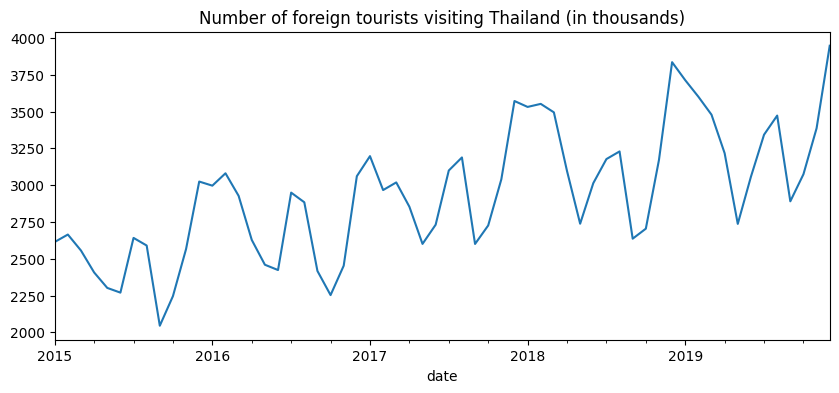

In [10]:
df = pd.read_excel("thai_tour.xlsx", header=None)
df.columns = ["date", "value"]
df["date"] = pd.to_datetime(df["date"])
df = df.set_index("date").sort_index()

y = df["value"].astype(float)
y.index = y.index.to_period("M")

y.plot(figsize=(10,4), title="Number of foreign tourists visiting Thailand (in thousands)")

In [11]:
# Split sample
h = 24

y_in = y.iloc[:-h]
y_out = y.iloc[-h:]

In [12]:
best_parameters_store = {}

# --- Running Average method
yhat_ra = helper.running_average_forecast(y_in)
u_ra = helper.forecast_errors(y_in, yhat_ra)
metrics_ra = helper.forecast_metrics(u_ra, y_in, tau=14)
ME_ra, MAE_ra, MAPE_ra, MSE_ra = (
    metrics_ra["ME"], metrics_ra["MAE"], metrics_ra["MAPE"], metrics_ra["MSE"]
)

# --- Random Walk method
yhat_rw = helper.lag_forecast(y_in)
u_rw = helper.forecast_errors(y_in, yhat_rw)
metrics_rw = helper.forecast_metrics(u_rw, y_in, tau=14)
ME_rw, MAE_rw, MAPE_rw, MSE_rw = (
    metrics_rw["ME"], metrics_rw["MAE"], metrics_rw["MAPE"], metrics_rw["MSE"]
)

# # --- Exponential Smoothing method
# alphas = np.linspace(1e-4, 1, 2000)
# best_alpha, best_mse = None, np.inf
# for alpha in alphas:
#     yhat = helper.exp_smoothing_forecast(y_in, alpha)
#     mse = np.nanmean((y_in - yhat)**2)
#     if mse < best_mse:
#         best_mse = mse
#         best_alpha = alpha
# yhat_es = helper.exp_smoothing_forecast(y_in, alpha=best_alpha)
# u_es = helper.forecast_errors(y_in, yhat_es)
# metrics_es = helper.forecast_metrics(u_es, y_in, tau=14)
# ME_es, MAE_es, MAPE_es, MSE_es = (
#     metrics_es["ME"], metrics_es["MAE"], metrics_es["MAPE"], metrics_es["MSE"]
# )

# best_parameters_store["ExpSmo"] = best_alpha

# --- Exponential Smoothing method (expanding)
alpha_es_est, yhat_es_est, u_es_est = helper.estimate_alpha_exponential_smoothing(y_in)
metrics_es_est = helper.forecast_metrics(u_es_est, y_in, tau=14)
ME_es_est, MAE_es_est, MAPE_es_est, MSE_es_est = (
    metrics_es_est["ME"], metrics_es_est["MAE"], metrics_es_est["MAPE"], metrics_es_est["MSE"]
)

# --- Running Trend method
yhat_rt, a_hat, b_hat = helper.running_trend_forecast(y_in)
u_rt = helper.forecast_errors(y_in, yhat_rt)
metrics_rt = helper.forecast_metrics(u_rt, y_in, tau=14)
ME_rt, MAE_rt, MAPE_rt, MSE_rt = (
    metrics_rt["ME"], metrics_rt["MAE"], metrics_rt["MAPE"], metrics_rt["MSE"]
)

# --- Random Walk plus Drift method
_, yhat_rwd, _ = helper.random_walk_plus_drift_forecast(y_in)
u_rwd = helper.forecast_errors(y_in, yhat_rwd)
metrics_rwd = helper.forecast_metrics(u_rwd, y_in, tau=14)
ME_rwd, MAE_rwd, MAPE_rwd, MSE_rwd = (
    metrics_rwd["ME"], metrics_rwd["MAE"], metrics_rwd["MAPE"], metrics_rwd["MSE"]
)

# # --- Holt Winters method
# grid = np.linspace(1e-3, 1, 200)
# best_alpha, best_beta, best_mse = None, None, np.inf
# for alpha in grid:
#     for beta in grid:
#         yhat = helper.holt_fitted_forecast_series(y_in, alpha, beta)
#         mse = np.nanmean((y_in - yhat)**2)
#         if mse < best_mse:
#             best_mse = mse
#             best_alpha, best_beta = alpha, beta
# yhat_hw = helper.holt_fitted_forecast_series(y_in, best_alpha, best_beta)
# u_hw = helper.forecast_errors(y_in, yhat_hw)
# metrics_hw = helper.forecast_metrics(u_hw, y_in, tau=14)
# ME_hw, MAE_hw, MAPE_hw, MSE_hw = (
#     metrics_hw["ME"], metrics_hw["MAE"], metrics_hw["MAPE"], metrics_hw["MSE"]
# )

# best_parameters_store["HW"] = (best_alpha, best_beta)

# --- Holt Winters method (expanding)
alpha_hw_est, beta_hw_est, yhat_hw_est, u_hw_est, _ = helper.estimate_alpha_beta_holt_winters(y_in)
metrics_hw_est = helper.forecast_metrics(u_hw_est, y_in, tau=14)
ME_hw_est, MAE_hw_est, MAPE_hw_est, MSE_hw_est = (
    metrics_hw_est["ME"], metrics_hw_est["MAE"], metrics_hw_est["MAPE"], metrics_hw_est["MSE"]
)

# --- Running Seasonal Regression method
yhat_rsr, _, _, _ = helper.running_seasonal_regression_forecast(y_in, S=12)
u_rsr = helper.forecast_errors(y_in, yhat_rsr)
metrics_rsr = helper.forecast_metrics(u_rsr, y_in, tau=14)
ME_rsr, MAE_rsr, MAPE_rsr, MSE_rsr = (
    metrics_rsr["ME"], metrics_rsr["MAE"], metrics_rsr["MAPE"], metrics_rsr["MSE"]
)

# --- Seasonal Random Walk method
yhat_srw = helper.seasonal_random_walk_forecast(y_in, S=12)
u_srw = helper.forecast_errors(y_in, yhat_srw)
metrics_srw = helper.forecast_metrics(u_srw, y_in, tau=14)
ME_srw, MAE_srw, MAPE_srw, MSE_srw = (
    metrics_srw["ME"], metrics_srw["MAE"], metrics_srw["MAPE"], metrics_srw["MSE"]
)

# --- Seasonal Random Walk plus Drift method
yhat_srwd, _ = helper.seasonal_random_walk_with_drift_forecast(y_in, S=12)
u_srwd = helper.forecast_errors(y_in, yhat_srwd)
metrics_srwd = helper.forecast_metrics(u_srwd, y_in, tau=14)
ME_srwd, MAE_srwd, MAPE_srwd, MSE_srwd = (
    metrics_srwd["ME"], metrics_srwd["MAE"], metrics_srwd["MAPE"], metrics_srwd["MSE"]
)

# --- Seasonal Multiplicative Holt–Winter method
grid = np.linspace(1e-2, 1, 31)
best_alpha, best_beta, best_gamma, best_mse = None, None, None, np.inf
for alpha in grid:
    for beta in grid:
        for gamma in grid:
            yhat, _, _, _ = helper.holt_winters_multiplicative_forecast(y_in, S=12, alpha=alpha, beta=beta, gamma=gamma)
            mse = np.nanmean((y_in - yhat)**2)
            if mse < best_mse:
                best_mse = mse
                best_alpha, best_beta, best_gamma = alpha, beta, gamma
yhat_smhw, _, _, _ = helper.holt_winters_multiplicative_forecast(y_in, 12, best_alpha, best_beta, best_gamma)
u_smhw = helper.forecast_errors(y_in, yhat_smhw)
metrics_smhw = helper.forecast_metrics(u_smhw, y_in, tau=14)
ME_smhw, MAE_smhw, MAPE_smhw, MSE_smhw = (
    metrics_smhw["ME"], metrics_smhw["MAE"], metrics_smhw["MAPE"], metrics_smhw["MSE"]
)

best_parameters_store["SMHW"] = (best_alpha, best_beta, best_gamma)

# # --- Seasonal Multiplicative Holt–Winter method (expanding)
# _, _, _, yhat_smhw_est, u_smhw_est, _ = helper.estimate_alpha_beta_gamma_seasonal_hw(y_in, S=12, multiplicative=True)
# metrics_smhw_est = helper.forecast_metrics(u_smhw_est, y_in, tau=14)
# ME_smhw_est, MAE_smhw_est, MAPE_smhw_est, MSE_smhw_est = (
#     metrics_smhw_est["ME"], metrics_smhw_est["MAE"], metrics_smhw_est["MAPE"], metrics_smhw_est["MSE"]
# )

# --- Seasonal Additive Holt–Winter method
grid = np.linspace(1e-2, 1, 31)
best_alpha, best_beta, best_gamma, best_mse = None, None, None, np.inf
for alpha in grid:
    for beta in grid:
        for gamma in grid:
            yhat, _, _, _ = helper.holt_winters_additive_forecast(y_in, S=12, alpha=alpha, beta=beta, gamma=gamma)
            mse = np.nanmean((y_in - yhat)**2)
            if mse < best_mse:
                best_mse = mse
                best_alpha, best_beta, best_gamma = alpha, beta, gamma
yhat_sahw, _, _, _ = helper.holt_winters_additive_forecast(y_in, 12, best_alpha, best_beta, best_gamma)
u_sahw = helper.forecast_errors(y_in, yhat_sahw)
metrics_sahw = helper.forecast_metrics(u_sahw, y_in, tau=14)
ME_sahw, MAE_sahw, MAPE_sahw, MSE_sahw = (
    metrics_sahw["ME"], metrics_sahw["MAE"], metrics_sahw["MAPE"], metrics_sahw["MSE"]
)

best_parameters_store["SAHW"] = (best_alpha, best_beta, best_gamma)

# # --- Seasonal Additive Holt–Winter method (expanding)
# _, _, _, yhat_sahw_est, u_sahw_est, _ = helper.estimate_alpha_beta_gamma_seasonal_hw(y_in, S=12, multiplicative=False)
# metrics_sahw_est = helper.forecast_metrics(u_sahw_est, y_in, tau=14)
# ME_sahw_est, MAE_sahw_est, MAPE_sahw_est, MSE_sahw_est = (
#     metrics_sahw_est["ME"], metrics_sahw_est["MAE"], metrics_sahw_est["MAPE"], metrics_sahw_est["MSE"]
# )

/Users/liji/Documents/Y2blck3_TIF20123_Forecasting_Methods/forecasting_methods/AssignmentI/helper.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  csum += y[i]                    # Update cumulative sum
/Users/liji/Documents/Y2blck3_TIF20123_Forecasting_Methods/forecasting_methods/AssignmentI/helper.py:31: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ra[i] = (csum - y[i]) / i   # Average of values up to t-1
/Users/liji/Documents/Y2blck3_TIF20123_Forecasting_Methods/forecasting_methods/AssignmentI/helper.py:1023: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, inte

In [13]:
# --- ASCII table output (line_eq / line_dash style) ---
title = "FORECAST COMPARISONS, LAST 23 FORECASTS"
line_eq = "=" * 60
line_dash = "-" * 60

print(title)
print(line_eq)
print(f"{'Method':<30}{'ME':>7}{'MAE':>7}{'MAPE':>8}{'MSE':>7}")
print(line_dash)

print(f"{'Running Avg':<30}{ME_ra:>7.2f}{MAE_ra:>7.2f}{MAPE_ra:>8.2f}{MSE_ra:>12.2f}")
print(f"{'Random Walk':<30}{ME_rw:>7.2f}{MAE_rw:>7.2f}{MAPE_rw:>8.2f}{MSE_rw:>12.2f}")
# print(f"{'Exp Smo':<30}{ME_es:>7.2f}{MAE_es:>7.2f}{MAPE_es:>8.2f}{MSE_es:>12.2f}")
print(f"{'Exp Smo (expanding)':<30}{ME_es_est:>7.2f}{MAE_es_est:>7.2f}{MAPE_es_est:>8.2f}{MSE_es_est:>12.2f}")
print(f"{'Running Trend':<30}{ME_rt:>7.2f}{MAE_rt:>7.2f}{MAPE_rt:>8.2f}{MSE_rt:>12.2f}")
print(f"{'Random Walk plus Drift':<30}{ME_rwd:>7.2f}{MAE_rwd:>7.2f}{MAPE_rwd:>8.2f}{MSE_rwd:>12.2f}")
# print(f"{'Holt-Winters':<30}{ME_hw:>7.2f}{MAE_hw:>7.2f}{MAPE_hw:>8.2f}{MSE_hw:>12.2f}")
print(f"{'Holt-Winters (expanding)':<30}{ME_hw_est:>7.2f}{MAE_hw_est:>7.2f}{MAPE_hw_est:>8.2f}{MSE_hw_est:>12.2f}")
print(f"{'Running Sea. Regression':<30}{ME_rsr:>7.2f}{MAE_rsr:>7.2f}{MAPE_rsr:>8.2f}{MSE_rsr:>12.2f}")
print(f"{'Sea. Random Walk':<30}{ME_srw:>7.2f}{MAE_srw:>7.2f}{MAPE_srw:>8.2f}{MSE_srw:>12.2f}")
print(f"{'Sea. Random Walk plus Drift':<30}{ME_srwd:>7.2f}{MAE_srwd:>7.2f}{MAPE_srwd:>8.2f}{MSE_srwd:>12.2f}")
print(f"{'Sea. Multi. Holt-Winters':<30}{ME_smhw:>7.2f}{MAE_smhw:>7.2f}{MAPE_smhw:>8.2f}{MSE_smhw:>12.2f}")
# print(f"{'Sea. Multi. Holt-Winters (expanding)':<30}{ME_smhw_est:>7.2f}{MAE_smhw_est:>7.2f}{MAPE_smhw_est:>8.2f}{MSE_smhw_est:>12.2f}")
print(f"{'Sea. Addit. Holt-Winters':<30}{ME_sahw:>7.2f}{MAE_sahw:>7.2f}{MAPE_sahw:>8.2f}{MSE_sahw:>12.2f}")
# print(f"{'Sea. Addit. Holt-Winters (expanding)':<30}{ME_sahw_est:>7.2f}{MAE_sahw_est:>7.2f}{MAPE_sahw_est:>8.2f}{MSE_sahw_est:>12.2f}")


print(line_eq)
print("ME = Mean Error")
print("MAE = Mean Absolute Error")
print("MAPE = Mean Absolute Percentage Error")
print("MSE = Mean Squared Error")

FORECAST COMPARISONS, LAST 23 FORECASTS
Method                             ME    MAE    MAPE    MSE
------------------------------------------------------------
Running Avg                    205.69 304.66   10.29   135378.49
Random Walk                     25.01 250.23    8.85    93682.00
Exp Smo (expanding)             25.01 250.23    8.85    93682.00
Running Trend                    3.83 281.95   10.13   100455.02
Random Walk plus Drift          16.10 253.49    8.98    97151.58
Holt-Winters (expanding)       -23.99 248.83    8.92    93953.11
Running Sea. Regression        -28.47 124.53    4.60    25040.29
Sea. Random Walk               229.83 249.62    8.68    84721.76
Sea. Random Walk plus Drift    -25.76 144.84    5.26    35858.86
Sea. Multi. Holt-Winters         0.19 134.09    4.86    27948.12
Sea. Addit. Holt-Winters        -5.16 120.84    4.43    24681.66
ME = Mean Error
MAE = Mean Absolute Error
MAPE = Mean Absolute Percentage Error
MSE = Mean Squared Error


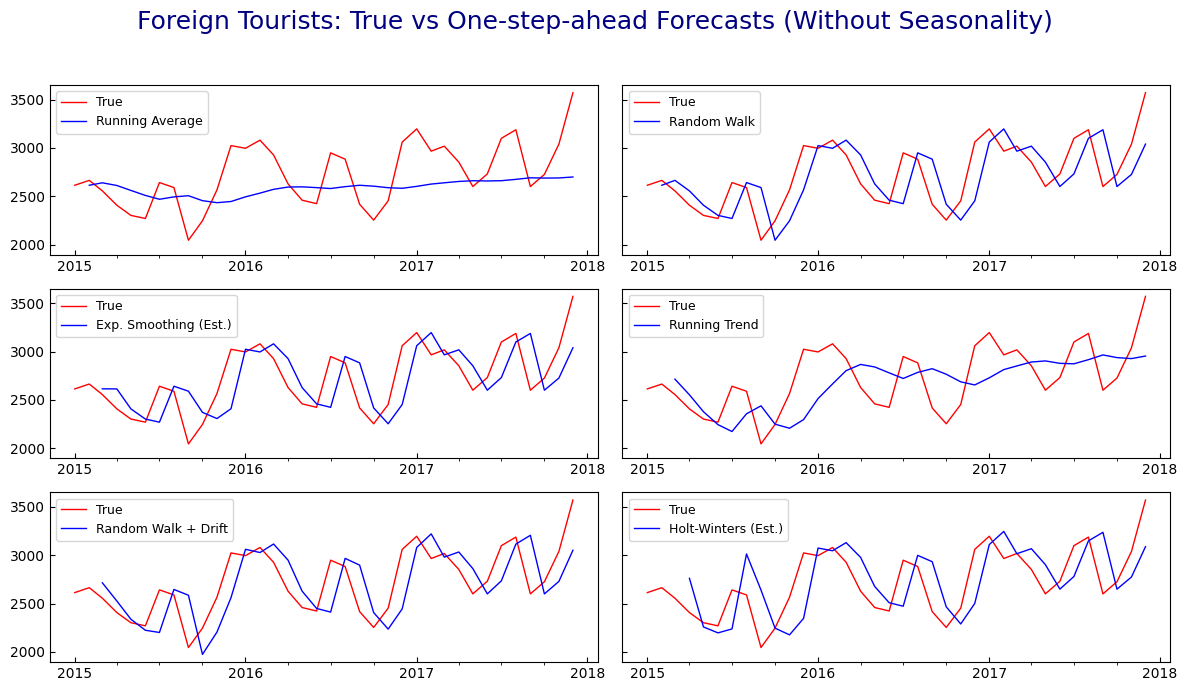

In [14]:
# ----------------------------
# Panels
# ----------------------------
panels = [
    ("Running Average", yhat_ra),
    ("Random Walk", yhat_rw),
    # ("Exp. Smoothing ", yhat_es),
    ("Exp. Smoothing (Est.)", yhat_es_est),

    ("Running Trend", yhat_rt),
    ("Random Walk + Drift", yhat_rwd),
    # ("Holt-Winters", yhat_hw),
    ("Holt-Winters (Est.)", yhat_hw_est),

    ("Running Seasonal Regression", yhat_rsr),
    ("Seasonal RW", yhat_srw),
    ("Seasonal RW + Drift", yhat_srwd),
    ("Seasonal HW (Multiplicative)", yhat_smhw),
    ("Seasonal HW (Additive)", yhat_sahw),
]


# ----------------------------
# Plot (3x2)
# ----------------------------
x = y_in.index.to_timestamp()
y_true = y_in


# ===== Group 1: Methods 1–6 =====
group1 = panels[0:6]

fig, axs = plt.subplots(3, 2, figsize=(12, 7), sharex=True, sharey=True)
fig.suptitle("Foreign Tourists: True vs One-step-ahead Forecasts (Without Seasonality)", color="navy", fontsize=18, y=0.98)

axs = axs.ravel()

for i, (lab, yhat) in enumerate(group1):
    ax = axs[i]
    ax.plot(x, y_true, color="red", linewidth=1.0, label="True")
    ax.plot(x, yhat, color="blue", linewidth=1.0, label=lab)

    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))

    ax.tick_params(direction="in")
    ax.grid(False)
    ax.legend(loc="upper left", fontsize=9, frameon=True)

for j in range(len(group1), len(axs)):
    axs[j].axis("off")

for ax in axs:
    ax.tick_params(labelbottom=True)

for ax in axs:
    ax.set_xlabel("")
    ax.set_ylabel("")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

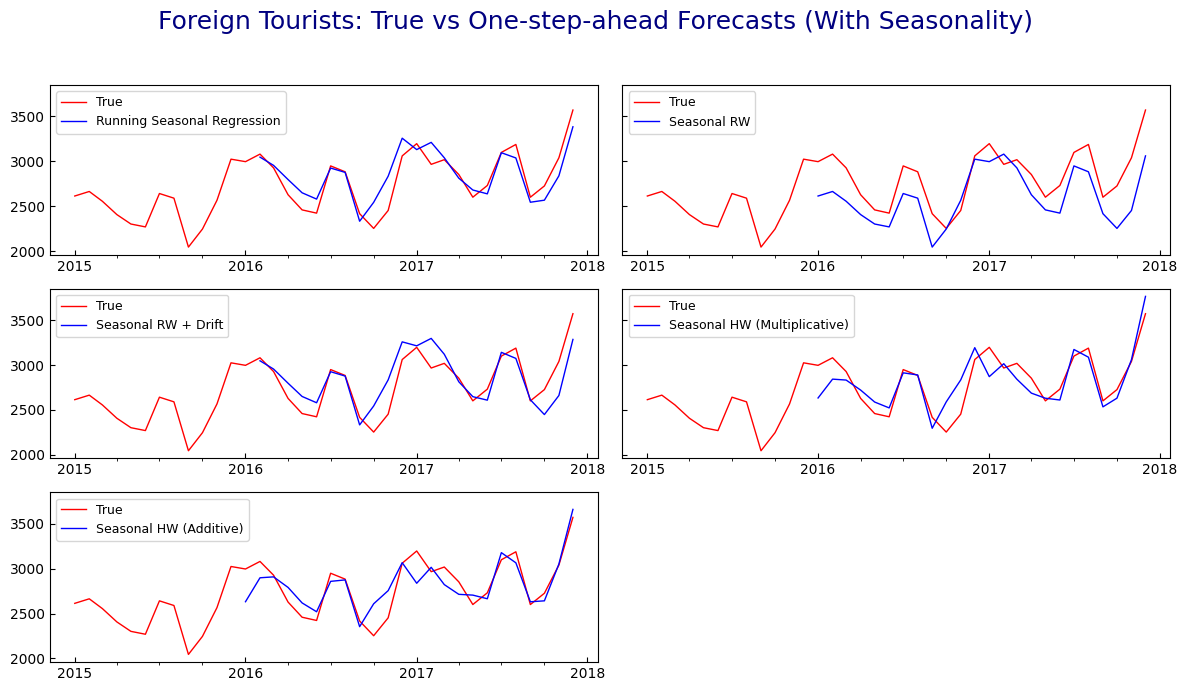

In [15]:
# ===== Group 2: Methods 6–11 =====
group1 = panels[6:11]

fig, axs = plt.subplots(3, 2, figsize=(12, 7), sharex=True, sharey=True)
fig.suptitle("Foreign Tourists: True vs One-step-ahead Forecasts (With Seasonality)", color="navy", fontsize=18, y=0.98)

axs = axs.ravel()

for i, (lab, yhat) in enumerate(group1):
    ax = axs[i]
    ax.plot(x, y_true, color="red", linewidth=1.0, label="True")
    ax.plot(x, yhat, color="blue", linewidth=1.0, label=lab)
    
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))

    ax.tick_params(direction="in")
    ax.grid(False)
    ax.legend(loc="upper left", fontsize=9, frameon=True)

for j in range(len(group1), len(axs)):
    axs[j].axis("off")

for ax in axs:
    ax.tick_params(labelbottom=True)

for ax in axs:
    ax.set_xlabel("")
    ax.set_ylabel("")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### Out-of-sample Assessment

In [16]:
n = len(y_in)
tau_oos = n + 1

# --- Running Average method
yhat_ra = helper.running_average_forecast(y)
u_ra = helper.forecast_errors(y, yhat_ra)
metrics_ra = helper.forecast_metrics(u_ra, y, tau=tau_oos)
ME_ra, MAE_ra, MAPE_ra, MSE_ra = (
    metrics_ra["ME"], metrics_ra["MAE"], metrics_ra["MAPE"], metrics_ra["MSE"]
)

# --- Random Walk method
yhat_rw = helper.lag_forecast(y)
u_rw = helper.forecast_errors(y, yhat_rw)
metrics_rw = helper.forecast_metrics(u_rw, y, tau=tau_oos)
ME_rw, MAE_rw, MAPE_rw, MSE_rw = (
    metrics_rw["ME"], metrics_rw["MAE"], metrics_rw["MAPE"], metrics_rw["MSE"]
)


# # --- Exponential Smoothing method (alpha = 0.8)
# alpha = best_parameters_store["ExpSmo"]
# yhat_es = helper.exp_smoothing_forecast(y, alpha=alpha)
# u_es = helper.forecast_errors(y, yhat_es)
# metrics_es = helper.forecast_metrics(u_es, y, tau=tau_oos)
# ME_es, MAE_es, MAPE_es, MSE_es = (
#     metrics_es["ME"], metrics_es["MAE"], metrics_es["MAPE"], metrics_es["MSE"]
# )

# --- Exponential Smoothing method (estimated)
alpha_es_est, yhat_es_est, u_es_est = helper.estimate_alpha_exponential_smoothing(y)
metrics_es_est = helper.forecast_metrics(u_es_est, y, tau=tau_oos)
ME_es_est, MAE_es_est, MAPE_es_est, MSE_es_est = (
    metrics_es_est["ME"], metrics_es_est["MAE"], metrics_es_est["MAPE"], metrics_es_est["MSE"]
)

# --- Running Trend method
yhat_rt, a_hat, b_hat = helper.running_trend_forecast(y)
u_rt = helper.forecast_errors(y, yhat_rt)
metrics_rt = helper.forecast_metrics(u_rt, y, tau=tau_oos)
ME_rt, MAE_rt, MAPE_rt, MSE_rt = (
    metrics_rt["ME"], metrics_rt["MAE"], metrics_rt["MAPE"], metrics_rt["MSE"]
)

# --- Random Walk plus Drift method
_, yhat_rwd, _ = helper.random_walk_plus_drift_forecast(y)
u_rwd = helper.forecast_errors(y, yhat_rwd)
metrics_rwd = helper.forecast_metrics(u_rwd, y, tau=tau_oos)
ME_rwd, MAE_rwd, MAPE_rwd, MSE_rwd = (
    metrics_rwd["ME"], metrics_rwd["MAE"], metrics_rwd["MAPE"], metrics_rwd["MSE"]
)

# # --- Holt Winters method
# alpha, beta = best_parameters_store["HW"]
# yhat_hw = helper.holt_fitted_forecast_series(y, alpha=alpha, beta=beta)
# u_hw = helper.forecast_errors(y, yhat_hw)
# metrics_hw = helper.forecast_metrics(u_hw, y, tau=tau_oos)
# ME_hw, MAE_hw, MAPE_hw, MSE_hw = (
#     metrics_hw["ME"], metrics_hw["MAE"], metrics_hw["MAPE"], metrics_hw["MSE"]
# )

# --- Holt Winters method (estimated)
_, _, yhat_hw_est, u_hw_est, _ = helper.estimate_alpha_beta_holt_winters(y)
metrics_hw_est = helper.forecast_metrics(u_hw_est, y, tau=tau_oos)
ME_hw_est, MAE_hw_est, MAPE_hw_est, MSE_hw_est = (
    metrics_hw_est["ME"], metrics_hw_est["MAE"], metrics_hw_est["MAPE"], metrics_hw_est["MSE"]
)

# --- Running Seasonal Regression method
yhat_rsr, _, _, _ = helper.running_seasonal_regression_forecast(y, S=12)
u_rsr = helper.forecast_errors(y, yhat_rsr)
metrics_rsr = helper.forecast_metrics(u_rsr, y, tau=tau_oos)
ME_rsr, MAE_rsr, MAPE_rsr, MSE_rsr = (
    metrics_rsr["ME"], metrics_rsr["MAE"], metrics_rsr["MAPE"], metrics_rsr["MSE"]
)

# --- Seasonal Random Walk method
yhat_srw = helper.seasonal_random_walk_forecast(y, S=12)
u_srw = helper.forecast_errors(y, yhat_srw)
metrics_srw = helper.forecast_metrics(u_srw, y, tau=tau_oos)
ME_srw, MAE_srw, MAPE_srw, MSE_srw = (
    metrics_srw["ME"], metrics_srw["MAE"], metrics_srw["MAPE"], metrics_srw["MSE"]
)

# --- Seasonal Random Walk plus Drift method
yhat_srwd, _ = helper.seasonal_random_walk_with_drift_forecast(y, S=12)
u_srwd = helper.forecast_errors(y, yhat_srwd)
metrics_srwd = helper.forecast_metrics(u_srwd, y, tau=tau_oos)
ME_srwd, MAE_srwd, MAPE_srwd, MSE_srwd = (
    metrics_srwd["ME"], metrics_srwd["MAE"], metrics_srwd["MAPE"], metrics_srwd["MSE"]
)

# --- Seasonal Multiplicative Holt–Winter method
alpha, beta, gamma = best_parameters_store["SMHW"]
yhat_smhw, _, _, _ = helper.holt_winters_multiplicative_forecast(y, S=12, alpha=alpha, beta=beta, gamma=gamma)
u_smhw = helper.forecast_errors(y, yhat_smhw)
metrics_smhw = helper.forecast_metrics(u_smhw, y, tau=tau_oos)
ME_smhw, MAE_smhw, MAPE_smhw, MSE_smhw = (
    metrics_smhw["ME"], metrics_smhw["MAE"], metrics_smhw["MAPE"], metrics_smhw["MSE"]
)

# _, _, _, yhat_smhw_est, u_smhw_est, _ = helper.estimate_alpha_beta_gamma_seasonal_hw(y, S=12, multiplicative=True)
# metrics_smhw_est = helper.forecast_metrics(u_smhw_est, y, tau=tau_oos)
# ME_smhw_est, MAE_smhw_est, MAPE_smhw_est, MSE_smhw_est = (
#     metrics_smhw_est["ME"], metrics_smhw_est["MAE"], metrics_smhw_est["MAPE"], metrics_smhw_est["MSE"]
# )

# --- Seasonal Additive Holt–Winter method
alpha, beta, gamma = best_parameters_store["SAHW"]
yhat_sahw, _, _, _ = helper.holt_winters_additive_forecast(y, S=12, alpha=alpha, beta=beta, gamma=gamma)
u_sahw = helper.forecast_errors(y, yhat_sahw)
metrics_sahw = helper.forecast_metrics(u_sahw, y, tau=tau_oos)
ME_sahw, MAE_sahw, MAPE_sahw, MSE_sahw = (
    metrics_sahw["ME"], metrics_sahw["MAE"], metrics_sahw["MAPE"], metrics_sahw["MSE"]
)

# # --- Seasonal Additive Holt–Winter method (expanding)
# _, _, _, yhat_sahw_est, u_sahw_est, _ = helper.estimate_alpha_beta_gamma_seasonal_hw(y, S=12, multiplicative=False)
# metrics_sahw_est = helper.forecast_metrics(u_sahw_est, y, tau=tau_oos)
# ME_sahw_est, MAE_sahw_est, MAPE_sahw_est, MSE_sahw_est = (
#     metrics_sahw_est["ME"], metrics_sahw_est["MAE"], metrics_sahw_est["MAPE"], metrics_sahw_est["MSE"]
# )

/Users/liji/Documents/Y2blck3_TIF20123_Forecasting_Methods/forecasting_methods/AssignmentI/helper.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  csum += y[i]                    # Update cumulative sum
/Users/liji/Documents/Y2blck3_TIF20123_Forecasting_Methods/forecasting_methods/AssignmentI/helper.py:31: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ra[i] = (csum - y[i]) / i   # Average of values up to t-1
/Users/liji/Documents/Y2blck3_TIF20123_Forecasting_Methods/forecasting_methods/AssignmentI/helper.py:1023: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, inte

In [17]:
# --- ASCII table output (line_eq / line_dash style) ---
title = "FORECAST COMPARISONS (Out-of-Sample), ALL 24 Observations"
line_eq = "=" * 60
line_dash = "-" * 60

print(title)
print(line_eq)
print(f"{'Method':<30}{'ME':>7}{'MAE':>7}{'MAPE':>8}{'MSE':>12}")
print(line_dash)

print(f"{'Running Avg':<30}{ME_ra:>7.2f}{MAE_ra:>7.2f}{MAPE_ra:>8.2f}{MSE_ra:>12.2f}")
print(f"{'Random Walk':<30}{ME_rw:>7.2f}{MAE_rw:>7.2f}{MAPE_rw:>8.2f}{MSE_rw:>12.2f}")
# print(f"{'Exp Smo':<30}{ME_es:>7.2f}{MAE_es:>7.2f}{MAPE_es:>8.2f}{MSE_es:>12.2f}")
print(f"{'Exp Smo':<30}{ME_es_est:>7.2f}{MAE_es_est:>7.2f}{MAPE_es_est:>8.2f}{MSE_es_est:>12.2f}")
print(f"{'Running Trend':<30}{ME_rt:>7.2f}{MAE_rt:>7.2f}{MAPE_rt:>8.2f}{MSE_rt:>12.2f}")
print(f"{'Random Walk plus Drift':<30}{ME_rwd:>7.2f}{MAE_rwd:>7.2f}{MAPE_rwd:>8.2f}{MSE_rwd:>12.2f}")
# print(f"{'Holt-Winters':<30}{ME_hw:>7.2f}{MAE_hw:>7.2f}{MAPE_hw:>8.2f}{MSE_hw:>12.2f}")
print(f"{'Holt-Winters':<30}{ME_hw_est:>7.2f}{MAE_hw_est:>7.2f}{MAPE_hw_est:>8.2f}{MSE_hw_est:>12.2f}")
print(f"{'Running Sea. Regression':<30}{ME_rsr:>7.2f}{MAE_rsr:>7.2f}{MAPE_rsr:>8.2f}{MSE_rsr:>12.2f}")
print(f"{'Sea. Random Walk':<30}{ME_srw:>7.2f}{MAE_srw:>7.2f}{MAPE_srw:>8.2f}{MSE_srw:>12.2f}")
print(f"{'Sea. Random Walk plus Drift':<30}{ME_srwd:>7.2f}{MAE_srwd:>7.2f}{MAPE_srwd:>8.2f}{MSE_srwd:>12.2f}")
print(f"{'Sea. Multi. Holt-Winters':<30}{ME_smhw:>7.2f}{MAE_smhw:>7.2f}{MAPE_smhw:>8.2f}{MSE_smhw:>12.2f}")
# print(f"{'Sea. Multi. Holt-Winters':<30}{ME_smhw_est:>7.2f}{MAE_smhw_est:>7.2f}{MAPE_smhw_est:>8.2f}{MSE_smhw_est:>12.2f}")
print(f"{'Sea. Addit. Holt-Winters':<30}{ME_sahw:>7.2f}{MAE_sahw:>7.2f}{MAPE_sahw:>8.2f}{MSE_sahw:>12.2f}")
# print(f"{'Sea. Addit. Holt-Winters':<30}{ME_sahw_est:>7.2f}{MAE_sahw_est:>7.2f}{MAPE_sahw_est:>8.2f}{MSE_sahw_est:>12.2f}")


print(line_eq)
print("ME = Mean Error")
print("MAE = Mean Absolute Error")
print("MAPE = Mean Absolute Percentage Error")
print("MSE = Mean Squared Error")

FORECAST COMPARISONS (Out-of-Sample), ALL 24 Observations
Method                             ME    MAE    MAPE         MSE
------------------------------------------------------------
Running Avg                    415.84 458.52   13.30   300962.15
Random Walk                     15.65 276.40    8.76   114258.25
Exp Smo                         15.65 276.40    8.76   114258.25
Running Trend                  -23.80 307.01    9.70   142039.55
Random Walk plus Drift           1.76 280.94    8.91   116493.92
Holt-Winters                   -31.93 276.30    8.78   115872.33
Running Sea. Regression        -45.00 118.68    3.81    20191.43
Sea. Random Walk               180.18 183.44    5.53    55609.90
Sea. Random Walk plus Drift    -50.10 132.08    4.17    25496.48
Sea. Multi. Holt-Winters       -13.37  87.66    2.76    11372.09
Sea. Addit. Holt-Winters        -9.55  83.07    2.63    11621.17
ME = Mean Error
MAE = Mean Absolute Error
MAPE = Mean Absolute Percentage Error
MSE = Mean Squared Er

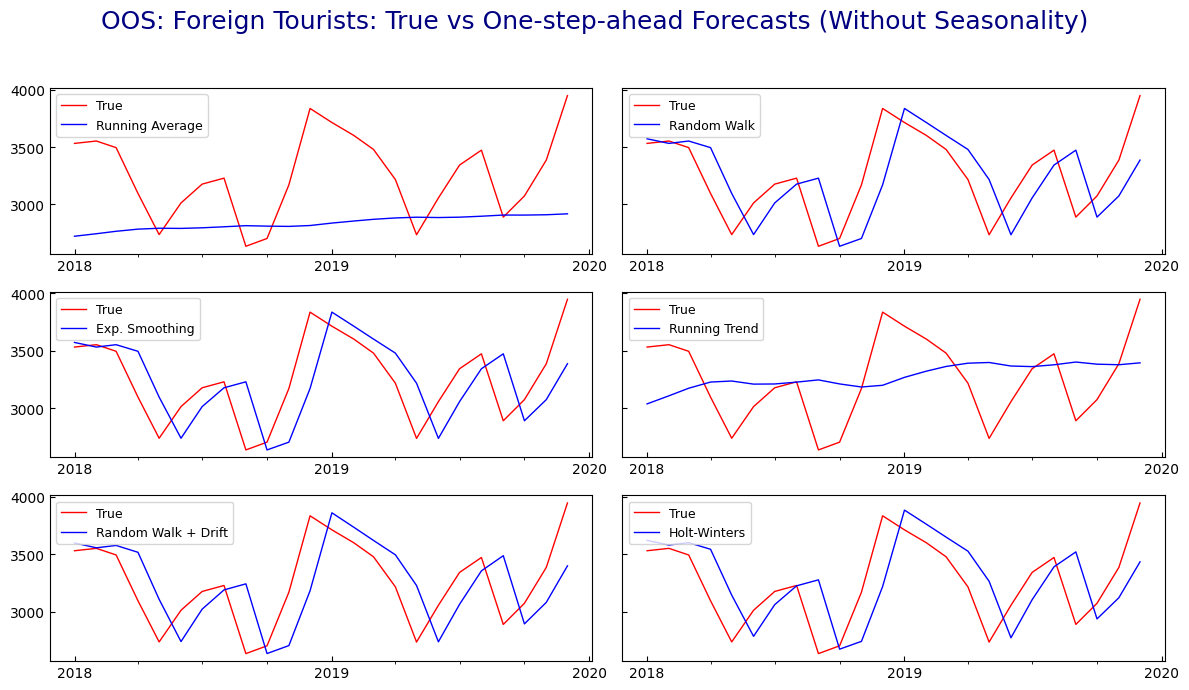

In [19]:
# ----------------------------
# Panels
# ----------------------------
panels = [
    ("Running Average", yhat_ra[n:]),
    ("Random Walk", yhat_rw[n:]),
    ("Exp. Smoothing", yhat_es_est[n:]),

    ("Running Trend", yhat_rt[n:]),
    ("Random Walk + Drift", yhat_rwd[n:]),
    ("Holt-Winters", yhat_hw_est[n:]),

    ("Running Seasonal Regression", yhat_rsr[n:]),
    ("Seasonal RW", yhat_srw[n:]),
    ("Seasonal RW + Drift", yhat_srwd[n:]),
    ("Seasonal HW (Multiplicative)", yhat_smhw[n:]),
    ("Seasonal HW (Additive)", yhat_sahw[n:]),
]


# ----------------------------
# Plot (3x2)
# ----------------------------
x = y_out.index.to_timestamp()
y_true = y_out


# ===== Group 1: Methods 1–6 =====
group1 = panels[0:6]

fig, axs = plt.subplots(3, 2, figsize=(12, 7), sharex=True, sharey=True)
fig.suptitle("OOS: Foreign Tourists: True vs One-step-ahead Forecasts (Without Seasonality)", color="navy", fontsize=18, y=0.98)

axs = axs.ravel()

for i, (lab, yhat) in enumerate(group1):
    ax = axs[i]
    ax.plot(x, y_true, color="red", linewidth=1.0, label="True")
    ax.plot(x, yhat, color="blue", linewidth=1.0, label=lab)

    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))

    ax.tick_params(direction="in")
    ax.grid(False)
    ax.legend(loc="upper left", fontsize=9, frameon=True)

for j in range(len(group1), len(axs)):
    axs[j].axis("off")

for ax in axs:
    ax.tick_params(labelbottom=True)

for ax in axs:
    ax.set_xlabel("")
    ax.set_ylabel("")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

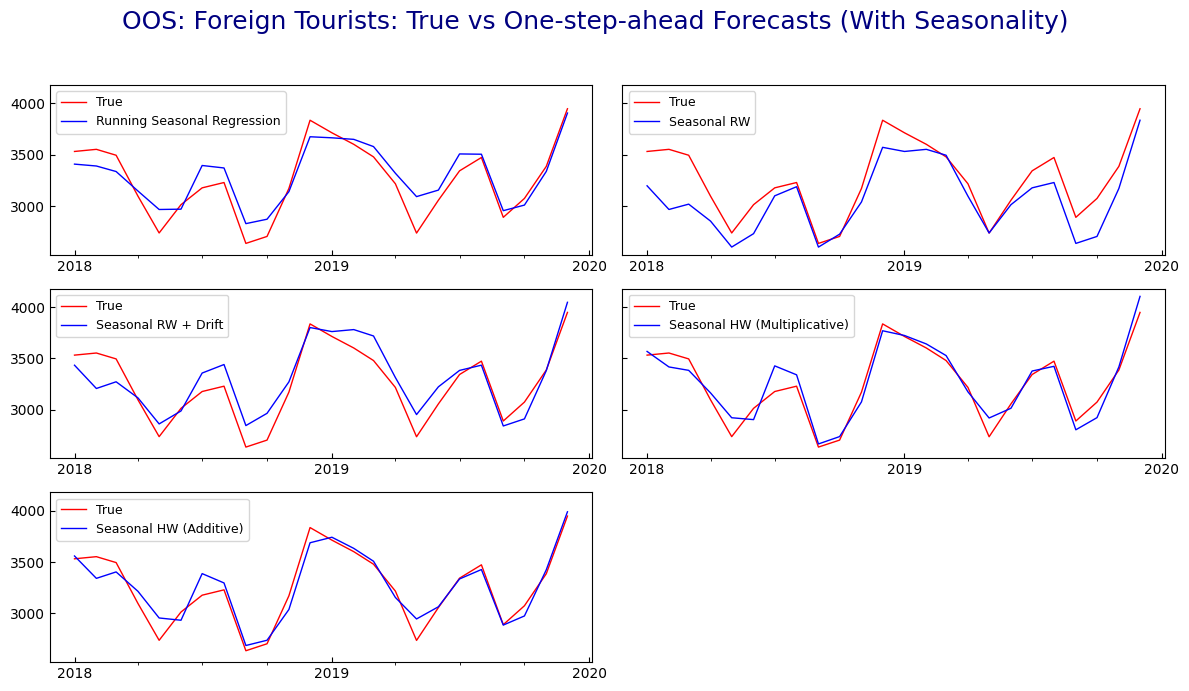

In [20]:
# ===== Group 2: Methods 6–11 =====
group1 = panels[6:11]

fig, axs = plt.subplots(3, 2, figsize=(12, 7), sharex=True, sharey=True)
fig.suptitle("OOS: Foreign Tourists: True vs One-step-ahead Forecasts (With Seasonality)", color="navy", fontsize=18, y=0.98)

axs = axs.ravel()

for i, (lab, yhat) in enumerate(group1):
    ax = axs[i]
    ax.plot(x, y_true, color="red", linewidth=1.0, label="True")
    ax.plot(x, yhat, color="blue", linewidth=1.0, label=lab)
    
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))

    ax.tick_params(direction="in")
    ax.grid(False)
    ax.legend(loc="upper left", fontsize=9, frameon=True)

for j in range(len(group1), len(axs)):
    axs[j].axis("off")

for ax in axs:
    ax.tick_params(labelbottom=True)

for ax in axs:
    ax.set_xlabel("")
    ax.set_ylabel("")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()